In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from utils.model_saver import *
from utils.model_classes import XGBModel

PROJECT_ROOT = Path().resolve().parent.parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")
PATH_DATA = PROJECT_ROOT / 'data' / 'exploded_splits'
print(f"Data: {PATH_DATA}")

TEXTUAL_EMBEDDING_PATH = PROJECT_ROOT / 'data' / 'textual_features'
MODEL_SAVE_PATH = PROJECT_ROOT / 'Models'
text_emb_64 = TEXTUAL_EMBEDDING_PATH / 'textual_embeddings_64.parquet'

RANDOM_STATE = 42

import torch
# Detect device: 'cuda' if available, else 'cpu'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# for parallelization
N_JOBS = -1 if not torch.cuda.is_available() else 1

Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1
Data: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/data/exploded_splits
Using device: cuda


# XGB Model - on textual embeddings
By leveraging textual embeddings (64-dimensional vectors representing paper content), we treat the problem as a supervised learning task.

To ensure code quality and reusability, we implement a custom class hierarchy:

- `BaseModel`: An abstract class that defines the blueprint for all models. It enforces the implementation of `preprocess()` method and provides standardized `train_pipeline` and `test_pipeline` methods.

- `XGBModel`: The concrete implementation of the baseline. It encapsulates the feature engineering logic (dropping non-feature columns) and stateful preprocessing (storing a `StandardScaler` to ensure the test set is scaled using training statistics).


## 1. Import dataframe with embeddings

In [3]:
df = pd.read_parquet(text_emb_64)
display(df.head())
print(df.shape)

,split,article_id,ref_id,is_reference_valid,article_emb_000,article_emb_001,article_emb_002,article_emb_003,article_emb_004,article_emb_005,...,ref_emb_054,ref_emb_055,ref_emb_056,ref_emb_057,ref_emb_058,ref_emb_059,ref_emb_060,ref_emb_061,ref_emb_062,ref_emb_063
0,train,53e99f0ab7602d97027d6a89,53e99ff0b7602d97028d14d3,1,0.256074,-0.008567,0.029544,0.027869,-0.039098,0.061620,...,0.076582,0.055348,-0.039177,0.056256,0.017018,0.043579,0.034777,0.014663,-0.034044,-0.054704
1,train,53e9bd81b7602d9704a24d06,557f4d4f6fee0fe990cb035f,1,0.177240,0.009656,-0.006378,0.139191,0.036752,0.024424,...,-0.006508,0.031545,-0.055565,-0.011979,-0.008363,-0.009386,0.002395,-0.002766,0.006723,-0.022802
2,train,539087fe20f70186a0d75db6,539087ae20f70186a0d4cf5a,1,0.279532,-0.065988,0.089001,-0.124467,0.029971,-0.064336,...,0.038588,-0.011394,0.045359,0.087640,-0.039526,0.060604,-0.010542,-0.043045,-0.086090,-0.061507
3,train,539087fe20f70186a0d75db6,5390878e20f70186a0d3a260,1,0.279532,-0.065988,0.089001,-0.124467,0.029971,-0.064336,...,-0.075838,0.037070,-0.002920,-0.001729,0.016099,0.013601,0.073003,0.078989,-0.067062,-0.089302
4,train,539087fe20f70186a0d75db6,539087cb20f70186a0d58fe1,1,0.279532,-0.065988,0.089001,-0.124467,0.029971,-0.064336,...,-0.031528,0.011389,-0.031854,-0.024054,0.068860,0.031421,-0.216782,0.017370,0.027655,-0.016881


(2950135, 132)


In [4]:
# splitting
split_series = df["split"].astype(str).str.lower()
df_train = df[split_series == "train"].copy()
df_val = df[split_series.isin(["validation", "val"])].copy()
df_test = df[split_series == "test"].copy()

print("\nSplit sizes:", {"train": len(df_train), "test": len(df_test), "val": len(df_val)})


Split sizes: {'train': 2162513, 'test': 396380, 'val': 391242}


## 2. Baseline Model

[XGB_baseline] Preprocessing 2162513 rows...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[XGB_baseline] Starting training...
Selected 21625/2162513
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     10827
           1     1.0000    1.0000    1.0000     10798

    accuracy                         1.0000     21625
   macro avg     1.0000    1.0000    1.0000     21625
weighted avg     1.0000    1.0000    1.0000     21625



/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [10:22:17] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


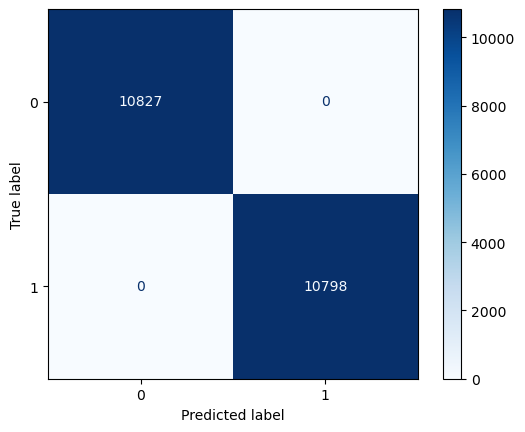

In [5]:
XGB_baseline = XGBModel('XGB_baseline', tree_method="hist")
XGB_baseline.train_pipeline(df_train, )

[XGB_baseline] Preprocessing 10000 rows...
Label distribution:
is_reference_valid
1    0.503
0    0.497
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.8213    0.8044    0.8128      4970
           1     0.8106    0.8270    0.8187      5030

    accuracy                         0.8158     10000
   macro avg     0.8159    0.8157    0.8158     10000
weighted avg     0.8159    0.8158    0.8158     10000



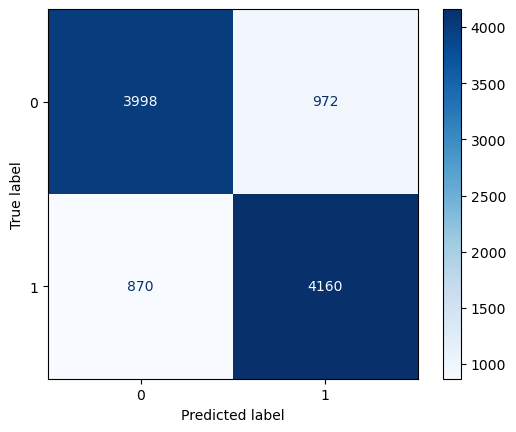

In [6]:
XGB_baseline.test_pipeline(df_test.sample(10000))

## 3. Hypertuning
Given the high dimensionality of features and the complexity of the `XGBoost` algorithm, performing an exhaustive search of all parameter combinations is computationally prohibitive. To optimize performance, we utilize `RandomizedSearchCV` instead of `GridSearchCV`.

While `GridSearchCV` evaluates every possible combination in a fixed grid, `RandomizedSearchCV` samples a fixed number of parameter settings from specified distributions. This approach allows us to explore a wider range of hyperparameters (like learning rate, tree depth, and regularization) more efficiently, often finding an optimal solution in a fraction of the time.

For the cross-validation strategy, we use a 2-fold approach (cv=2) on a controlled subset. This ensures that the model's generalization is tested across different data partitions while keeping the memory footprint low, which is critical when working with GPU-accelerated training and large embedding arrays on Windows systems.

In [7]:
# Valid hyperparameters for XGBClassifier
param_dist = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1, 5, 10],
    "scale_pos_weight": [1, 2, 5],
}

[XGB_textual_64] Grid Search...
[XGB_textual_64] Preprocessing 2162513 rows...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[XGB_textual_64] Preprocessing 391242 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
[XGB_textual_64] CUDA detected: using n_jobs=1 for RandomizedSearchCV to avoid running multiple GPU fits at the same time.
Fitting 2 folds for each of 20 candidates, totalling 40 fits
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=10, n_estimators=100, reg_lambda=5, scale_pos_weight=5, subsample=1.0; total time=  10.4s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=10, n_estimators=100, reg_lambda=5, scale_pos_weight=5, subsample=1.0; total time=  10.5s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, reg_lambda=10, scale_pos_weight=5, subsample=0.8; total time=   4.6s
[CV] END colsample_bytree=0.8, learning_rate=0.0

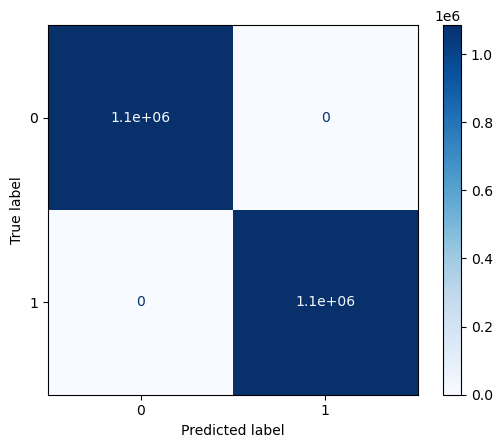

In [8]:
# tuning
XGB_textual_64 = XGBModel("XGB_textual_64", tree_method="hist")
XGB_textual_64.hypertune_pipeline(df_train, df_val, param_dist, 
                            n_iter=20,
                            cv=2,
                            scoring="f1",
                            random_state=RANDOM_STATE,
                            n_jobs=N_JOBS,
                            pre_dispatch="2*n_jobs",
                            error_score="raise",
                            verbose=2,
                            frac=1
                        )

## 4. Final model with best params
Once the optimal hyperparameters (number of neighbors, weight function, and distance metric) are found, the model is retrained on the full training set.

Performance is assessed using:
- Weighted F1-Score: To account for any slight imbalances in class distribution.
- Confusion Matrix: To visualize Type I and Type II errors.
- Classification Report: Providing precision, recall, and accuracy at a granular level.

[XGB_textual_64] Preprocessing 396380 rows...
Label distribution:
is_reference_valid
1    0.500003
0    0.499997
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.8327    0.8478    0.8402    198189
           1     0.8450    0.8296    0.8372    198191

    accuracy                         0.8387    396380
   macro avg     0.8388    0.8387    0.8387    396380
weighted avg     0.8388    0.8387    0.8387    396380



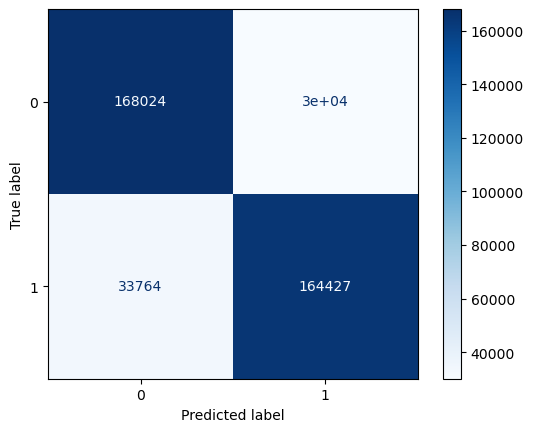

In [9]:
# final training creating model with best params
XGB_textual_64.test_pipeline(df_test)

## 5. Save the Model pretrained
Finally, the trained model and its associated metadata (parameters, data source name, and performance summary) are saved using a custom `save_model_artifact` utility, allowing for easy deployment or further testing.

In [13]:
from utils.model_saver import save_model_artifact

save_model_artifact(XGB_textual_64, df_name=text_emb_64.name, 
                    model_name="Best_XGB_textual_64", 
                    relative_model_dir=MODEL_SAVE_PATH)